In [1]:
import yfinance as yf
import pandas as pd

ticker = "BBRI.JK"
df = yf.download(ticker, start="2020-01-01", end="2026-09-01")

# Ratakan kolom MultiIndex jadi kolom biasa
df.columns = df.columns.get_level_values(0)

print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(1606, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,2680.164062,2680.164062,2649.776650,2674.086547,45886302
2020-01-03,2686.241211,2698.396240,2668.008830,2686.241211,91189705
2020-01-06,2655.854004,2668.008870,2625.466594,2649.776489,48648450
2020-01-07,2674.086182,2680.163696,2661.931316,2680.163696,114344885
2020-01-08,2661.931152,2674.086017,2637.621260,2661.931152,188929583


In [2]:
df.to_csv("../data/raw/bbri_historical.csv")
print(f"Tersimpan: {len(df)} baris data")

Tersimpan: 1606 baris data


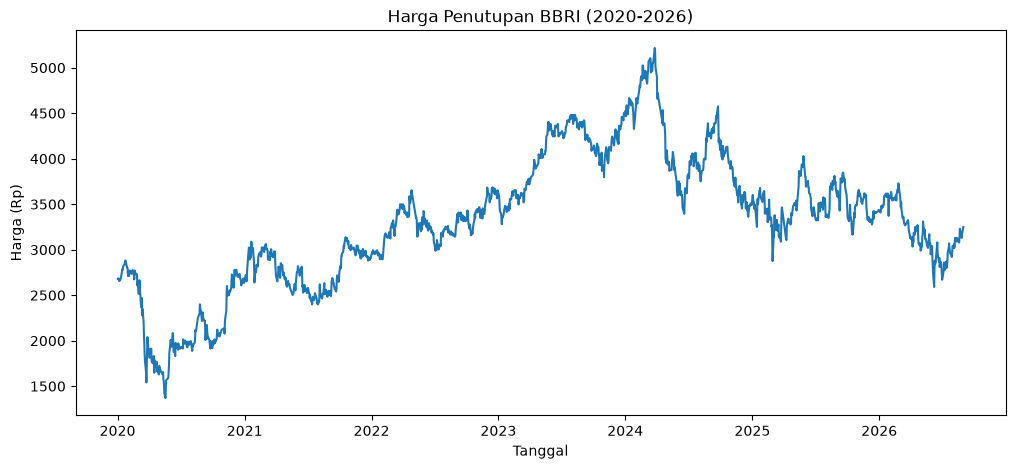

In [3]:
# EDA
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'])
plt.title('Harga Penutupan BBRI (2020-2026)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rp)')
plt.show()

In [4]:
df.describe()

Price,Close,High,Low,Open,Volume
count,1606.000000,1606.000000,1606.000000,1606.000000,1.606000e+03
mean,3303.733765,3345.049148,3268.065550,3307.777132,1.991937e+08
std,715.846829,716.347605,713.572381,713.648568,1.242847e+08
min,1370.257324,1433.402872,1363.942727,1420.773567,0.000000e+00
25%,2870.000000,2917.445306,2829.188389,2875.417807,1.144311e+08
50%,3341.512573,3380.542238,3310.495247,3340.198566,1.656362e+08
75%,3715.992371,3756.591618,3680.158869,3719.784591,2.424186e+08
max,5216.774414,5237.476041,5154.670096,5216.774555,1.073662e+09


In [5]:
# memeriksa apakah ada tanggal yang hilang (misal hari libur, atau data kosong)
print("Rentang tanggal:", df.index.min(), "sampai", df.index.max())
print("Jumlah hari kalender dalam rentang itu:", (df.index.max() - df.index.min()).days)
print("Jumlah baris data (hari bursa):", len(df))

Rentang tanggal: 2020-01-02 00:00:00 sampai 2026-08-31 00:00:00
Jumlah hari kalender dalam rentang itu: 2433
Jumlah baris data (hari bursa): 1606


In [6]:
zero_volume_days = df[df['Volume'] == 0]
print(f"Jumlah hari dengan volume 0: {len(zero_volume_days)}")
zero_volume_days

Jumlah hari dengan volume 0: 5


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-05-14,3120.0,3120.0,3120.0,3120.0,0
2026-05-15,3120.0,3120.0,3120.0,3120.0,0
2026-05-27,3070.0,3070.0,3070.0,3070.0,0
2026-05-28,3070.0,3070.0,3070.0,3070.0,0
2026-08-25,3180.0,3180.0,3180.0,3180.0,0


In [7]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [8]:
df.to_csv("../data/raw/bbri_historical.csv")
print(f"Tersimpan: {len(df)} baris data")

Tersimpan: 1606 baris data
